# 03 · A minimal U-Net on the link channels: the interface, not a result

This notebook shows how a learned model plugs into the dataset and the scoring: a tiny U-Net
(about 30 000 weights) reads the four rasterized link channels and predicts the hourly radar field,
trained for a few epochs on a laptop CPU. **It is a minimal interface example, not a result.**
Nothing is tuned; the numbers below say only that the pipeline runs end to end, not how well a
CNN can do. Choosing, training and judging a model is the project's work.

* train on the training events, keep the epoch with the lowest loss on the validation events;
* score once on the test events, with the same table as the baselines (notebook 02);
* loss: mean squared error of $\log(1+R)$ on the scored cells (within 2 km of a link).

**Runtime:** about two and a half minutes, most of it training.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")    # PyTorch and other OpenMP users in one process

import sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects/maps/learned_2d/src"))

from core.data_paths import OUTPUTS
from core.maps import learning as ml

CACHE = OUTPUTS / "_learned_2d"          # generated files, not tracked
SPLIT_COLORS = {"train": "#3b6fb6", "val": "#e08a2e", "test": "#c03b3b"}
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
T0 = time.time()
import torch
from core.maps import map_skill as sk
from learned_2d.baselines import baseline_maps, fit_variogram
from learned_2d.unet import TinyUNet, fit, predict

torch.manual_seed(0)
torch.set_num_threads(min(4, os.cpu_count() or 1))       # the setup cell limits OpenMP to one thread

In [2]:
ds = ml.build_network_dataset("openmrg", cache_dir=CACHE)     # built by notebook 01, read from the cache
test = ds.sel(time=ds.split == "test")
mask = ds.observable.values.astype(bool)
check = test.gauges.sel(station=test.station_set.isin(["city", "smhi"]))    # independent check gauges
print(f"test: {test.sizes['time']} hours of {len(set(test.event_id.values))} events; "
      f"{int(mask.sum())} scored cells; {check.sizes['station']} check gauges")

test: 102 hours of 5 events; 852 scored cells; 11 check gauges


In [3]:
data = {s: ml.arrays(ds, s) for s in ml.SPLITS}
model = TinyUNet(n_in=len(ml.CHANNELS), c=(8, 16, 32))
print({s: d["x"].shape for s, d in data.items()}, f"{sum(p.numel() for p in model.parameters()):,} weights")
t = time.time()
history = pd.DataFrame(fit(model, data["train"]["x"], data["train"]["y"], mask,
                           data["val"]["x"], data["val"]["y"], epochs=25, batch=16, lr=3e-3))
print(f"25 epochs in {time.time() - t:.0f} s; best validation epoch {int(history.val.idxmin()) + 1}")

{'train': (188, 4, 35, 51), 'val': (51, 4, 35, 51), 'test': (102, 4, 35, 51)} 29,537 weights


25 epochs in 101 s; best validation epoch 24


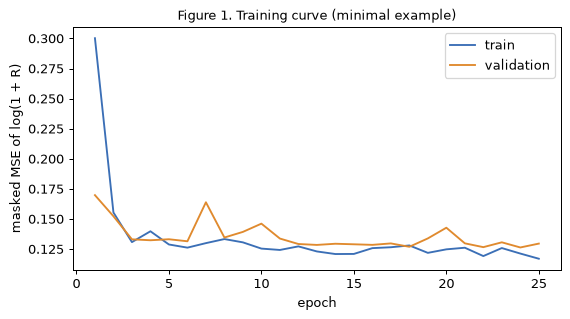

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(history.epoch, history.train, color=SPLIT_COLORS["train"], label="train")
ax.plot(history.epoch, history.val, color=SPLIT_COLORS["val"], label="validation")
ax.set(xlabel="epoch", ylabel="masked MSE of log(1 + R)", title="Figure 1. Training curve (minimal example)")
ax.legend(); plt.show()

## Scored with the baselines' table

The U-Net predicts every cell; it is scored on the same cells, hours and gauges as the baselines.

In [5]:
unet = test.target.copy(data=predict(model, data["test"]["x"]))
maps = baseline_maps(test, fit_variogram(ds, "train"))
table = sk.skill_table({**maps, "tiny U-Net (example)": unet}, test.target, event=test.event_id,
                       mask=mask, gauges=check, threshold=0.1)
pd.set_option("display.precision", 3)
table

,n,rmse,mae,bias,pcc,pcc_step,event_bias,event_abs_rel_error,pod,far,csi,gauge_n,gauge_rmse,gauge_mae,gauge_bias,gauge_pcc
method,,,,,,,,,,,,,,,,
idw,86659,1.032,0.460,-0.252,0.683,0.372,-5.118,0.592,0.414,0.169,0.382,1122,0.736,0.317,-0.186,0.831
ok,86659,1.039,0.463,-0.248,0.678,0.377,-5.047,0.586,0.419,0.164,0.387,1122,0.879,0.372,-0.155,0.775
gmz,86659,1.034,0.461,-0.248,0.682,0.365,-5.046,0.582,0.411,0.177,0.378,1122,0.730,0.313,-0.203,0.834
tiny U-Net (example),86659,1.058,0.518,-0.017,0.644,0.316,-0.338,0.271,1.000,0.509,0.491,1122,0.910,0.441,0.170,0.830


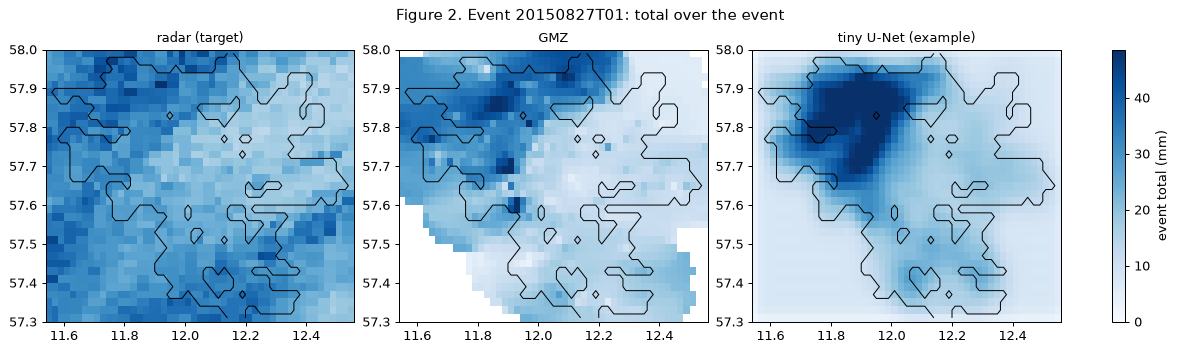

runtime 137 s


In [6]:
ev = test.event_total_mm.where(test.event_split == "test").idxmax().item()
sel = test.event_id == ev
fields = {"radar (target)": test.target, "GMZ": maps["gmz"], "tiny U-Net (example)": unet}
vmax = float(test.target.sel(time=sel).sum("time").where(test.observable == 1).max())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
for ax, (name, m) in zip(axes, fields.items()):
    pm = ax.pcolormesh(test.lon, test.lat, m.sel(time=sel).sum("time", min_count=1), cmap="Blues", vmin=0, vmax=vmax, shading="auto")
    ax.contour(test.lon, test.lat, mask, levels=[0.5], colors="k", linewidths=0.8); ax.set_title(name)
fig.colorbar(pm, ax=axes.tolist(), label="event total (mm)")
fig.suptitle(f"Figure 2. Event {ev}: total over the event"); plt.show()
print(f"runtime {time.time() - T0:.0f} s")

## Your method goes here

Replace `TinyUNet` / `fit` / `predict` with the project's model; keep the data
(`ml.arrays(ds, split)` or the link table) and the scoring (`sk.skill_table`) as they are, so every
number stays comparable with the baselines. Pointers for the proposal's other families:

* **Graph neural network.** Nodes = links (or link endpoints), features from the link table:
  `ds.link_rain`, `ds.link_attenuation`, `ds.frequency`, `ds.polarization`, `ds.length` and the
  coordinates (`ml.link_rain_of(ds)` gathers them); a missing link is NaN in that hour, so the graph
  changes from hour to hour. Grid cells (`ds.lat`, `ds.lon`) are the query points; a decoder from
  link embeddings to cells (attention or k-nearest links) gives the field. PyTorch Geometric is not
  installed in the FieldSense environment.
* **Diffusion prior (Moufad et al., 2026).** Train an unconditional generative model on radar fields
  (the training events' `ds.target`, or a longer radar record), then sample the posterior given the
  links with the exact path-integral forward operator: `ml.path_weights` gives the matrix of path
  shares per cell, `ml.sample_paths` applies it, and `core.cml.power_law.itu_ab` gives each link's
  $(a, b)$ for $A_i = a_i \int R^{b_i}\,dl$. The ensemble spread is a by-product.
* **Kriging with external drift.** `core.maps.mergeplg_methods.Merger(drift, links=...).field("ked")`
  already does block KED of the links with a drift field (there the radar); a learned or
  climatological drift can take its place.

```python
# est: (time, lat, lon) on test's grid and hours, mm in the hour
sk.skill_table({**maps, "mine": est}, test.target, event=test.event_id, mask=mask, gauges=check)
```